In [1]:
# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')
print("✅ All dependencies installed and ready!")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jebarajj\AppData\Roaming\nltk_data...


✅ All dependencies installed and ready!


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [2]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime
# ── Data handling ────────────────────────────────────────────────
import pandas as pd
# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup
# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports successful!")

✅ All imports successful!


In [3]:
NEWS_API_KEY = "a75936f4a7374373a2cf3a8c67f46715"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us"
BASE_URL = "https://newsapi.org/v2"

In [4]:
all_articles = []

In [5]:
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/top-headlines"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "category": category,
       "country": country,
       "pageSize" : page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles
for cat in CATEGORIES:
   articles = fetch_top_headlines(category=cat, country=COUNTRY)
   for art in articles:
       art["query_category"] = cat
   all_articles.extend(articles)
print(all_articles)


https://newsapi.org/v2/top-headlines
{'apiKey': 'a75936f4a7374373a2cf3a8c67f46715', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': 'the-verge', 'name': 'The Verge'}, 'author': 'Sean Hollister', 'title': 'Valve just imported 50 tons of game consoles in two days - The Verge', 'description': 'Valve imported roughly 50 tons of “Game Consoles” into the United States in the two-day period between May 1st and April 30th, according to import records.', 'url': 'https://www.theverge.com/news/923461/valve-steam-machine-frame-deck-import-records-may-2026', 'urlToImage': 'https://platform.theverge.com/wp-content/uploads/sites/2/2025/11/258049_Valve_2025_EverythingTimeStudio_0014.jpg?quality=90&strip=all&crop=0%2C10.805700988947%2C100%2C78.388598022106&w=1200', 'publishedAt': '2026-05-04T23:58:44Z', 'content': '<ul><li></li><li></li><li></li></ul>\r\nTheres reason to believe they could be the Steam Machine.\r\nTheres reason to believe they could be the 

In [6]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/everything"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "q": query,
       "language": "en",
       "sortBy": "publishedAt",
       "pageSize": page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles
for query in SEARCH_QUERIES:
   articles = fetch_by_keyword(query=query)
   for art in articles:
       art["query_category"] = f"kw:{query}"
   all_articles.extend(articles)

for art in all_articles:
   print(art)

https://newsapi.org/v2/everything
{'apiKey': 'a75936f4a7374373a2cf3a8c67f46715', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Bank of Canada'}, 'author': None, 'title': 'Monetary Policy ReportApril 2026 - Bank of Canada', 'description': 'The Canadian economy is expected to grow at a moderate pace as it continues to adjust to US tariffs. Inflation has moved up due to higher oil prices linked to the war in the Middle East. It is projected to then ease back to the 2% target in 2027.', 'url': 'https://www.bankofcanada.ca/publications/mpr/mpr-2026-04-29/', 'urlToImage': 'https://www.bankofcanada.ca/wp-content/uploads/2022/01/default-og-image.jpg', 'publishedAt': '2026-05-05T03:03:51Z', 'content': 'Before the outbreak of the war in the Middle East, the Canadian economy was evolving as expected. Since the war began, oil prices have risen, pushing inflation up, and the outlook has become more unc… [+6 chars]'}]
htt

In [7]:
print(json.dumps(all_articles, indent=2))

[
  {
    "source": {
      "id": "the-verge",
      "name": "The Verge"
    },
    "author": "Sean Hollister",
    "title": "Valve just imported 50 tons of game consoles in two days - The Verge",
    "description": "Valve imported roughly 50 tons of \u201cGame Consoles\u201d into the United States in the two-day period between May 1st and April 30th, according to import records.",
    "url": "https://www.theverge.com/news/923461/valve-steam-machine-frame-deck-import-records-may-2026",
    "urlToImage": "https://platform.theverge.com/wp-content/uploads/sites/2/2025/11/258049_Valve_2025_EverythingTimeStudio_0014.jpg?quality=90&strip=all&crop=0%2C10.805700988947%2C100%2C78.388598022106&w=1200",
    "publishedAt": "2026-05-04T23:58:44Z",
    "content": "<ul><li></li><li></li><li></li></ul>\r\nTheres reason to believe they could be the Steam Machine.\r\nTheres reason to believe they could be the Steam Machine.\r\nby\r\nSean HollisterClose\r\nPosts from this au\u2026 [+4144 chars]",
    "qu

In [8]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
   rows = []
   for art in articles:
       rows.append({
           "title": art.get("title") or "",
           "description" : art.get("description") or "",
           "source" : art.get("source", {}).get("name") or "Unknown",
           "url": art.get("url") or "",
           "published_at" : art.get("publishedAt") or "",
           "category" : art.get("query_category"),
           "full_text" : " ".join(filter(None, [
               art.get("title") or "",
               art.get("description") or "",
               art.get("content") or ""
           ]))
       })
   df = pd.DataFrame(rows)
   return df

In [9]:
df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,Valve just imported 50 tons of game consoles i...,Valve imported roughly 50 tons of “Game Consol...,The Verge,https://www.theverge.com/news/923461/valve-ste...,2026-05-04T23:58:44Z,technology,Valve just imported 50 tons of game consoles i...
1,Monetary Policy ReportApril 2026 - Bank of Canada,The Canadian economy is expected to grow at a ...,Bank of Canada,https://www.bankofcanada.ca/publications/mpr/m...,2026-05-05T03:03:51Z,kw:economy,Monetary Policy ReportApril 2026 - Bank of Can...
2,How Crypto Projects Are Revolutionizing Custom...,Remember when the biggest marketing decision f...,Securitysenses.com,https://securitysenses.com/posts/how-crypto-pr...,2026-05-05T03:06:52Z,kw:artificial intelligence,How Crypto Projects Are Revolutionizing Custom...


In [10]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
   "url":         re.compile(r'https?://\S+'),
   #before → "Read more at https://bbc.com/news/article-123 today"
   #after  → "Read more at   today"
   "html_tag":    re.compile(r'<[^>]+>'),
   #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
   #after  → " BREAKING:  Markets  fall  sharply"
   "punctuation": re.compile(r'[^a-zA-Z\s]'),
   #before → "Apple stock up 3.4% — best day since 2021!"
   #after  → "Apple stock up      best day since      "
   "extra_space": re.compile(r'\s+'),
   #before → "Apple   stock    up      best   day"
   #after  → "Apple stock up best day"
   "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
   #input   → "AAPL and TSLA both rose as NASA announced funding"
   #extracts → ["AAPL", "TSLA", "NASA"]
   "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
   #input    → "Elon Musk met Tim Cook in New York yesterday"
   #extracts → ["Elon Musk", "Tim Cook", "New York"]
   "year":        re.compile(r'\b(19|20)\d{2}\b'),
   #input    → "The 2024 budget follows the 2023 deficit report"
   #extracts → ["2024", "2023"]
   "number":      re.compile(r'\b\d+\.?\d*\b'),
   #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
   #extracts → ["4.2", "1"]
   "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
   #before → "The economy shrank [+247 chars]"
   #after  → "The economy shrank  "
}

In [11]:
def clean_text(text: str) -> str:
   """Full regex cleaning pipeline for NLP."""
   text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
   text = PATTERNS["url"].sub(' ', text)             # remove URLs
   text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
   text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
   text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
   return text.strip().lower()

 

In [12]:
print(clean_text('Stocks fell 4.2 points and GDP grew by 1 percent'))

 

stocks fell points and gdp grew by percent


In [13]:
def extract_proper_nouns(text: str) -> list:
   """Extract likely named entities using a regex heuristic."""
   return PATTERNS["proper_noun"].findall(text)

print(extract_proper_nouns('Elon Musk met Tim Cook in New York yesterday'))

['Elon Musk', 'Tim Cook', 'New York']


In [17]:
def extract_tickers(text: str) -> list:
   """Extract stock ticker / acronym candidates."""
   return PATTERNS["ticker"].findall(text)

In [14]:
df["clean_text"]    = df["full_text"].apply(clean_text)

In [15]:
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)

In [18]:
df["tickers"]       = df["title"].apply(extract_tickers)

In [19]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)


{'needn', "she'll", "he'll", 'and', 'do', 'further', 'be', 'is', "you'll", 'he', 'doing', 'just', 'down', 'but', "i'd", 'them', 'shouldn', "didn't", 'don', 'it', "haven't", 'ma', "they'd", 'a', "aren't", 'had', "i'll", 'yours', 'out', 'd', 'haven', 'that', 'under', 'once', 'theirs', 'were', 'other', 'too', 'hasn', 'here', 'how', 'between', 'same', 'will', 'few', 'we', 'all', 'has', 'before', "they'll", 'below', "shan't", 'won', 'against', 'off', 'been', 'only', "that'll", 'have', 'herself', 'above', 'o', 'until', 'about', 'of', 'this', 'the', 'myself', 'her', 'its', 'any', "we'd", 'ourselves', 'why', 'whom', "they've", 'which', 'hadn', 'at', 'through', 'own', "they're", "she's", 'doesn', 'didn', 'there', 'more', 'yourself', 'mustn', "you've", "we've", 'll', 'can', 'with', "wasn't", "couldn't", 'shan', 'over', 'his', 'nor', 'are', 'from', 'or', "he's", "it'd", 've', 'being', "i've", "we'll", 'you', 'mightn', 'now', "hadn't", 'when', 'they', 'for', "don't", "wouldn't", "you're", 'while',

In [20]:
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                  'would', 'could', 'may', 'will', 'get', 'got', 'year',
                  'first', 'last', 'week', 'day', 'time', 'report'])

In [21]:
def tokenize_and_filter(text: str) -> list:
   """Tokenize text and remove stopwords & short tokens."""
   tokens = word_tokenize(text)
   print('split into words', tokens)                            # split into words
   tokens = [t for t in tokens if t.isalpha()]    
   print(' keep only alphabetic', tokens)        # keep only alphabetic
   tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
   print('remove stopwords', tokens)
   tokens = [t for t in tokens if len(t) > 2]             # remove very short words
   print('remove very short words', tokens)
   return tokens

In [22]:
print(tokenize_and_filter('The 2024 budget by follows the 2023 deficit report'))

split into words ['The', '2024', 'budget', 'by', 'follows', 'the', '2023', 'deficit', 'report']
 keep only alphabetic ['The', 'budget', 'by', 'follows', 'the', 'deficit', 'report']
remove stopwords ['The', 'budget', 'follows', 'deficit']
remove very short words ['The', 'budget', 'follows', 'deficit']
['The', 'budget', 'follows', 'deficit']


In [23]:
 df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,Valve just imported 50 tons of game consoles i...,Valve imported roughly 50 tons of “Game Consol...,The Verge,https://www.theverge.com/news/923461/valve-ste...,2026-05-04T23:58:44Z,technology,Valve just imported 50 tons of game consoles i...,valve just imported tons of game consoles in t...,"[The Verge Valve, Game Consoles, United States...",[]
1,Monetary Policy ReportApril 2026 - Bank of Canada,The Canadian economy is expected to grow at a ...,Bank of Canada,https://www.bankofcanada.ca/publications/mpr/m...,2026-05-05T03:03:51Z,kw:economy,Monetary Policy ReportApril 2026 - Bank of Can...,monetary policy reportapril bank of canada the...,"[Monetary Policy Report, Canada The Canadian, ...",[]
2,How Crypto Projects Are Revolutionizing Custom...,Remember when the biggest marketing decision f...,Securitysenses.com,https://securitysenses.com/posts/how-crypto-pr...,2026-05-05T03:06:52Z,kw:artificial intelligence,How Crypto Projects Are Revolutionizing Custom...,how crypto projects are revolutionizing custom...,[How Crypto Projects Are Revolutionizing Custo...,[]


In [24]:
 # Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)

split into words ['valve', 'just', 'imported', 'tons', 'of', 'game', 'consoles', 'in', 'two', 'days', 'the', 'verge', 'valve', 'imported', 'roughly', 'tons', 'of', 'game', 'consoles', 'into', 'the', 'united', 'states', 'in', 'the', 'two', 'day', 'period', 'between', 'may', 'st', 'and', 'april', 'th', 'according', 'to', 'import', 'records', 'theres', 'reason', 'to', 'believe', 'they', 'could', 'be', 'the', 'steam', 'machine', 'theres', 'reason', 'to', 'believe', 'they', 'could', 'be', 'the', 'steam', 'machine', 'by', 'sean', 'hollisterclose', 'posts', 'from', 'this', 'au']
 keep only alphabetic ['valve', 'just', 'imported', 'tons', 'of', 'game', 'consoles', 'in', 'two', 'days', 'the', 'verge', 'valve', 'imported', 'roughly', 'tons', 'of', 'game', 'consoles', 'into', 'the', 'united', 'states', 'in', 'the', 'two', 'day', 'period', 'between', 'may', 'st', 'and', 'april', 'th', 'according', 'to', 'import', 'records', 'theres', 'reason', 'to', 'believe', 'they', 'could', 'be', 'the', 'steam'

In [25]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

In [26]:
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
   print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 134
Unique tokens: 88

Top 20 most frequent words:
  ads                     4
  days                    3
  war                     3
  crypto                  3
  marketing               3
  valve                   2
  imported                2
  tons                    2
  game                    2
  consoles                2
  theres                  2
  reason                  2
  believe                 2
  steam                   2
  machine                 2
  canadian                2
  economy                 2
  expected                2
  inflation               2
  oil                     2


In [27]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)

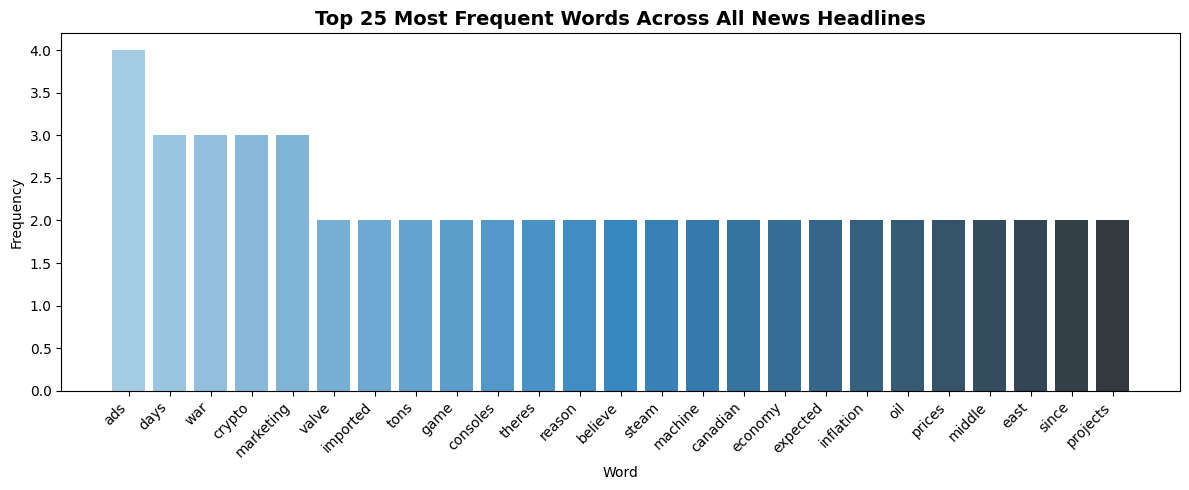

✅ Frequency chart displayed


In [28]:
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [29]:
text_for_cloud = " ".join(all_tokens)

In [30]:
print(all_tokens)

['valve', 'imported', 'tons', 'game', 'consoles', 'days', 'verge', 'valve', 'imported', 'roughly', 'tons', 'game', 'consoles', 'united', 'states', 'period', 'april', 'according', 'import', 'records', 'theres', 'reason', 'believe', 'steam', 'machine', 'theres', 'reason', 'believe', 'steam', 'machine', 'sean', 'hollisterclose', 'posts', 'monetary', 'policy', 'reportapril', 'bank', 'canada', 'canadian', 'economy', 'expected', 'grow', 'moderate', 'pace', 'continues', 'adjust', 'tariffs', 'inflation', 'moved', 'due', 'higher', 'oil', 'prices', 'linked', 'war', 'middle', 'east', 'projected', 'ease', 'back', 'target', 'outbreak', 'war', 'middle', 'east', 'canadian', 'economy', 'evolving', 'expected', 'since', 'war', 'began', 'oil', 'prices', 'risen', 'pushing', 'inflation', 'outlook', 'become', 'unc', 'crypto', 'projects', 'revolutionizing', 'customer', 'acquisition', 'web', 'marketing', 'remember', 'biggest', 'marketing', 'decision', 'project', 'whether', 'buy', 'google', 'ads', 'facebook', 

In [31]:
print(text_for_cloud)

valve imported tons game consoles days verge valve imported roughly tons game consoles united states period april according import records theres reason believe steam machine theres reason believe steam machine sean hollisterclose posts monetary policy reportapril bank canada canadian economy expected grow moderate pace continues adjust tariffs inflation moved due higher oil prices linked war middle east projected ease back target outbreak war middle east canadian economy evolving expected since war began oil prices risen pushing inflation outlook become unc crypto projects revolutionizing customer acquisition web marketing remember biggest marketing decision project whether buy google ads facebook ads days feel like ancient history watching crypto space evolve since honestly way projects acquiring users remember biggest marketing decision project whether buy google ads facebook ads days feel like ancient history watching crypto space evolve sinc


In [32]:
wc = WordCloud(
   width=900, height=400,
   background_color='white',
   colormap='RdYlGn',
   max_words=150,
   collocations=False
).generate(text_for_cloud)

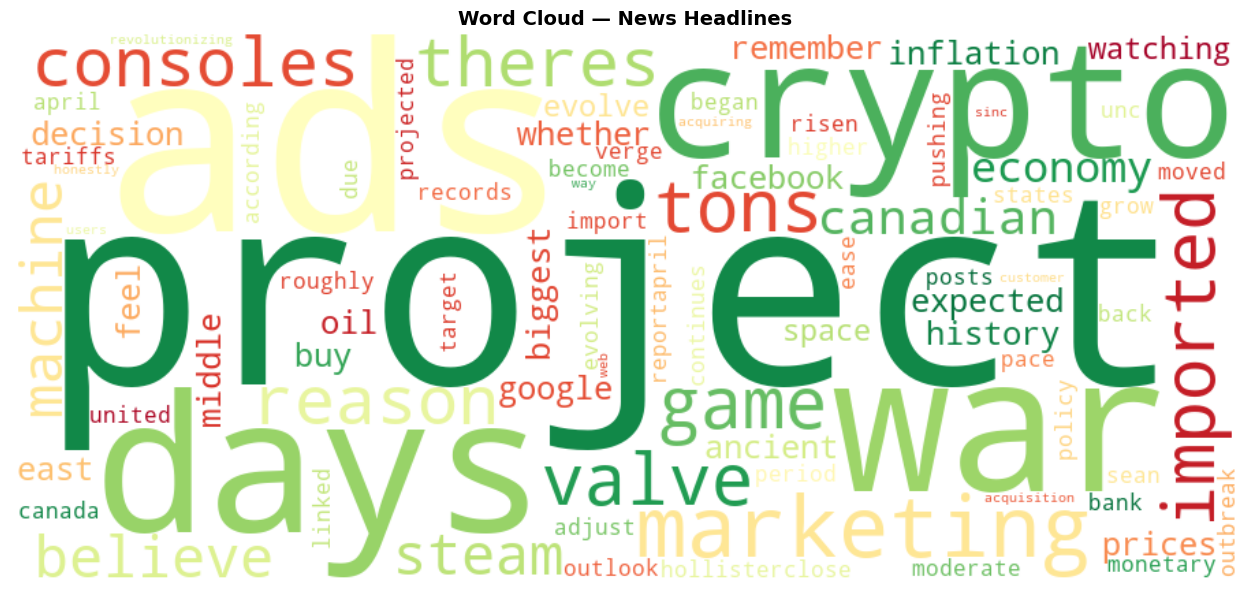

✅ Word cloud displayed


In [33]:
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [34]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('valve', 'NN'), ('imported', 'VBN'), ('tons', 'NNS'), ('game', 'NN'), ('consoles', 'NNS'), ('days', 'NNS'), ('verge', 'VBP'), ('valve', 'NN'), ('imported', 'VBN'), ('roughly', 'RB'), ('tons', 'NNS'), ('game', 'NN'), ('consoles', 'NNS'), ('united', 'JJ'), ('states', 'NNS'), ('period', 'NN'), ('april', 'IN'), ('according', 'VBG'), ('import', 'NN'), ('records', 'NNS'), ('theres', 'VBZ'), ('reason', 'NN'), ('believe', 'VBP'), ('steam', 'NN'), ('machine', 'NN'), ('theres', 'VBZ'), ('reason', 'NN'), ('believe', 'VBP'), ('steam', 'NN'), ('machine', 'NN'), ('sean', 'NN'), ('hollisterclose', 'JJ'), ('posts', 'NNS')]


In [35]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
   """Return counts of nouns, verbs, adjectives in a token list."""
   tagged = nltk.pos_tag(tokens)
   pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
   for _, tag in tagged:
       if tag.startswith("NN"): pos_counts["NN"] += 1
       elif tag.startswith("VB"): pos_counts["VB"] += 1
       elif tag.startswith("JJ"): pos_counts["JJ"] += 1
   return pos_counts

In [36]:
sample_df = df.head(50).copy()

In [37]:
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])
sample_df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count,pos_tags,noun_count,verb_count,adj_count
0,Valve just imported 50 tons of game consoles i...,Valve imported roughly 50 tons of “Game Consol...,The Verge,https://www.theverge.com/news/923461/valve-ste...,2026-05-04T23:58:44Z,technology,Valve just imported 50 tons of game consoles i...,valve just imported tons of game consoles in t...,"[The Verge Valve, Game Consoles, United States...",[],"[valve, imported, tons, game, consoles, days, ...",33,"{'NN': 21, 'VB': 8, 'JJ': 2}",21,8,2
1,Monetary Policy ReportApril 2026 - Bank of Canada,The Canadian economy is expected to grow at a ...,Bank of Canada,https://www.bankofcanada.ca/publications/mpr/m...,2026-05-05T03:03:51Z,kw:economy,Monetary Policy ReportApril 2026 - Bank of Can...,monetary policy reportapril bank of canada the...,"[Monetary Policy Report, Canada The Canadian, ...",[],"[monetary, policy, reportapril, bank, canada, ...",47,"{'NN': 21, 'VB': 11, 'JJ': 12}",21,11,12
2,How Crypto Projects Are Revolutionizing Custom...,Remember when the biggest marketing decision f...,Securitysenses.com,https://securitysenses.com/posts/how-crypto-pr...,2026-05-05T03:06:52Z,kw:artificial intelligence,How Crypto Projects Are Revolutionizing Custom...,how crypto projects are revolutionizing custom...,[How Crypto Projects Are Revolutionizing Custo...,[],"[crypto, projects, revolutionizing, customer, ...",54,"{'NN': 27, 'VB': 12, 'JJ': 9}",27,12,9


In [38]:
print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      23.0
  Avg verbs per headline:      10.3
  Avg adjectives per headline: 7.7
